Dataset shape: (1000, 8)

Column data types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Target Variable: math score

Missing values in each column:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

===== Experiment 1 - ReLU with lr = 0.01 ===telek==
Epoch 10 | LR=0.01 | Train Loss=4385.5522 | Val Loss=4543.9258
Epoch 20 | LR=0.01 | Train Loss=3245.7083 | Val Loss=3228.3704
Epoch 30 | LR=0.01 | Train Loss=1094.6777 | Val Loss=944.1320
Epoch 40 | LR=0.01 | Train Loss=320.6849 | Val Loss=301.77

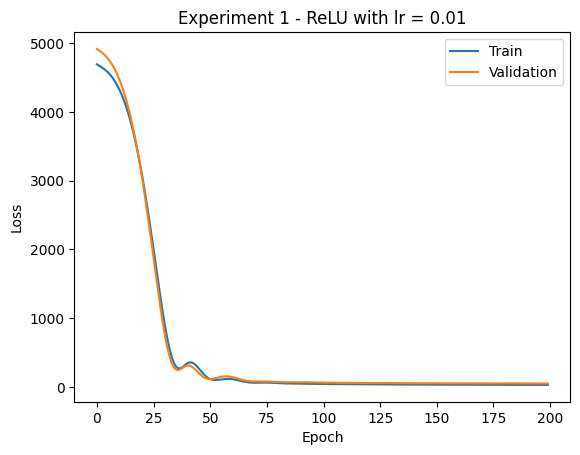


===== Experiment 2 - Tanh ===telek==
Epoch 10 | LR=0.01 | Train Loss=4579.0645 | Val Loss=4790.0645
Epoch 20 | LR=0.01 | Train Loss=4244.1392 | Val Loss=4445.4688
Epoch 30 | LR=0.01 | Train Loss=3954.7800 | Val Loss=4155.6802
Epoch 40 | LR=0.01 | Train Loss=3710.7092 | Val Loss=3906.7590
Epoch 50 | LR=0.01 | Train Loss=3484.7812 | Val Loss=3675.7512
Epoch 60 | LR=0.01 | Train Loss=3274.5588 | Val Loss=3460.5645
Epoch 70 | LR=0.01 | Train Loss=3078.5042 | Val Loss=3259.6169
Epoch 80 | LR=0.01 | Train Loss=2895.0571 | Val Loss=3071.3347
Epoch 90 | LR=0.01 | Train Loss=2722.8943 | Val Loss=2894.3984
Epoch 100 | LR=0.01 | Train Loss=2560.9636 | Val Loss=2727.7612
Epoch 110 | LR=0.01 | Train Loss=2408.4326 | Val Loss=2570.5962
Epoch 120 | LR=0.01 | Train Loss=2264.6294 | Val Loss=2422.2334
Epoch 130 | LR=0.01 | Train Loss=2128.9954 | Val Loss=2282.1179
Epoch 140 | LR=0.01 | Train Loss=2001.0527 | Val Loss=2149.7727
Epoch 150 | LR=0.01 | Train Loss=1880.3835 | Val Loss=2024.7811
Epoch 160 |

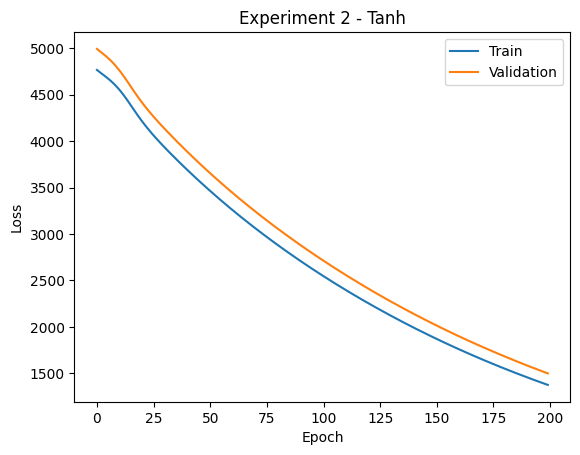


===== Experiment 3 - ReLU with lr = 0.001 ===telek==
Epoch 10 | LR=0.001 | Train Loss=4694.0781 | Val Loss=4939.8711
Epoch 20 | LR=0.001 | Train Loss=4675.2671 | Val Loss=4919.8042
Epoch 30 | LR=0.001 | Train Loss=4655.4189 | Val Loss=4898.2871
Epoch 40 | LR=0.001 | Train Loss=4631.8286 | Val Loss=4872.6299
Epoch 50 | LR=0.001 | Train Loss=4601.7485 | Val Loss=4840.1299
Epoch 60 | LR=0.001 | Train Loss=4562.6899 | Val Loss=4798.2070
Epoch 70 | LR=0.001 | Train Loss=4512.2920 | Val Loss=4744.2046
Epoch 80 | LR=0.001 | Train Loss=4447.7573 | Val Loss=4675.3174
Epoch 90 | LR=0.001 | Train Loss=4366.1025 | Val Loss=4588.5596
Epoch 100 | LR=0.001 | Train Loss=4264.5259 | Val Loss=4481.0327
Epoch 110 | LR=0.001 | Train Loss=4140.5190 | Val Loss=4350.1572
Epoch 120 | LR=0.001 | Train Loss=3991.9309 | Val Loss=4193.9292
Epoch 130 | LR=0.001 | Train Loss=3817.4382 | Val Loss=4011.0662
Epoch 140 | LR=0.001 | Train Loss=3616.3926 | Val Loss=3800.9700
Epoch 150 | LR=0.001 | Train Loss=3389.4963 |

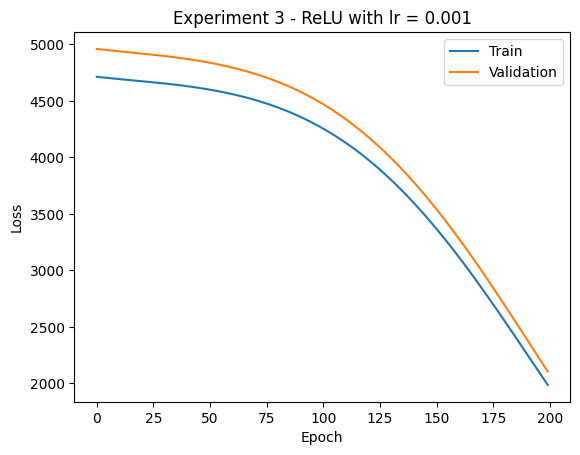


===== FINAL RESULTS =====
Experiment 1 - ReLU with lr = 0.01    Test MSE = 39.5248 | MAE = 4.9303 | R2 = 0.8210
Experiment 2 - Tanh    Test MSE = 1516.2203 | MAE = 36.2122 | R2 = -5.8681
Experiment 3 - ReLU with lr = 0.001 Test MSE = 2061.9524 | MAE = 43.6800 | R2 = -8.3401


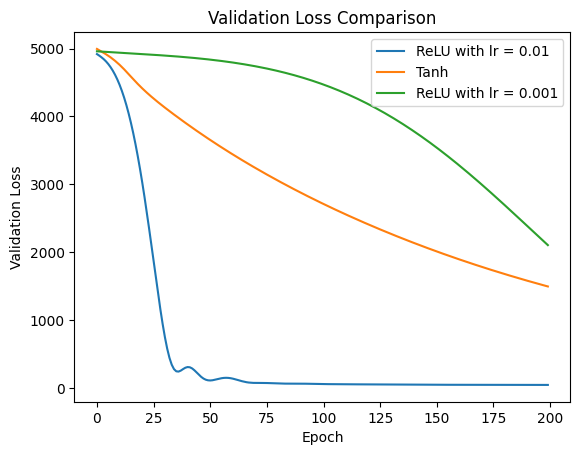

In [7]:
# =========================================
# IMPORT LIBRARIES
# =========================================

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# =========================================
# LOAD DATA
# =========================================

df = pd.read_csv("/content/exams.csv")

print("Dataset shape:", df.shape)
print("\nColumn data types:")
print(df.dtypes)

target_variable = "math score"
print("\nTarget Variable:", target_variable)

print("\nMissing values in each column:")
print(df.isna().sum())


# =========================================
# DATA PREPROCESSING
# =========================================

df_encoded = pd.get_dummies(df, drop_first=True)

target_variable = "math score"

X = df_encoded.drop(target_variable, axis=1)
y = df_encoded[target_variable]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train.values).view(-1, 1)

X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val.values).view(-1, 1)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test.values).view(-1, 1)

input_size = X_train.shape[1]


# =========================================
# MODEL CLASS
# =========================================

class MLP_Model(nn.Module):
    def __init__(self, input_size, activation):
        super(MLP_Model, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 32),
            activation,

            nn.Linear(32, 16),
            activation,

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)


# =========================================
# TRAINING FUNCTION
# =========================================

def train_model(model, lr, epochs=200):

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        model.train()

        preds = model(X_train)
        loss = criterion(preds, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()

        with torch.no_grad():
            val_preds = model(X_val)
            val_loss = criterion(val_preds, y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1} | LR={lr} | "
                f"Train Loss={loss.item():.4f} | "
                f"Val Loss={val_loss.item():.4f}"
            )

    return train_losses, val_losses


# =========================================
# EVALUATION FUNCTION
# =========================================

def evaluate(model):

    model.eval()

    with torch.no_grad():
        preds = model(X_test)
        mse = nn.MSELoss()(preds, y_test).item()
        mae = mean_absolute_error(y_test.numpy(), preds.numpy())
        r2 = r2_score(y_test.numpy(), preds.numpy())

    return mse, mae, r2


# =========================================
# RUN EXPERIMENT FUNCTION
# =========================================

def run_experiment(exp_name, activation, lr, epochs=200):

    print(f"\n===== {exp_name} ===telek==")

    model = MLP_Model(input_size, activation)

    train_loss, val_loss = train_model(
        model=model,
        lr=lr,
        epochs=epochs
    )

    mse, mae, r2 = evaluate(model)

    print(f"\n{exp_name} Test MSE = {mse:.4f}")
    print(f"{exp_name} Test MAE = {mae:.4f}")
    print(f"{exp_name} Test R2 = {r2:.4f}")

    plt.plot(train_loss, label="Train")
    plt.plot(val_loss, label="Validation")
    plt.title(exp_name)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig("results.png")
    plt.show()

    return model, train_loss, val_loss, mse, mae, r2


# =========================================
# EXPERIMENT 1 - ReLU with lr = 0.01
# =========================================

model1, train_loss1, val_loss1, mse1, mae1, r21 = run_experiment(
    exp_name="Experiment 1 - ReLU with lr = 0.01",
    activation=nn.ReLU(),
    lr=0.01,
    epochs=200
)


# =========================================
# EXPERIMENT 2 - Tanh
# =========================================

model2, train_loss2, val_loss2, mse2, mae2, r22 = run_experiment(
    exp_name="Experiment 2 - Tanh",
    activation=nn.Tanh(),
    lr=0.01,
    epochs=200
)


# =========================================
# EXPERIMENT 3 - ReLU with lr = 0.001
# =========================================

model3, train_loss3, val_loss3, mse3, mae3, r23 = run_experiment(
    exp_name="Experiment 3 - ReLU with lr = 0.001",
    activation=nn.ReLU(),
    lr=0.001,
    epochs=200
)


# =========================================
# FINAL COMPARISON
# =========================================

print("\n===== FINAL RESULTS =====")
print(f"Experiment 1 - ReLU with lr = 0.01    Test MSE = {mse1:.4f} | MAE = {mae1:.4f} | R2 = {r21:.4f}")
print(f"Experiment 2 - Tanh    Test MSE = {mse2:.4f} | MAE = {mae2:.4f} | R2 = {r22:.4f}")
print(f"Experiment 3 - ReLU with lr = 0.001 Test MSE = {mse3:.4f} | MAE = {mae3:.4f} | R2 = {r23:.4f}")


# =========================================
# COMPARE ALL VALIDATION LOSSES
# =========================================

plt.plot(val_loss1, label="ReLU with lr = 0.01")
plt.plot(val_loss2, label="Tanh")
plt.plot(val_loss3, label="ReLU with lr = 0.001")

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.savefig("results.png")
plt.show()